<a href="https://colab.research.google.com/github/phamhoquephuong/Ph-m-H-Qu-Ph-ng_31251021113_BTVN-1/blob/main/BTVN_HOA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [39]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/flower_photos"
img_width, img_height = 180,180
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='validation'
)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [52]:

import tensorflow as tf
from tensorflow.keras import layers, models


batch_size = 32
img_height = 180
img_width = 180
data_dir = "/content/drive/MyDrive/flower_photos"

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print('class names')


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


num_classes = len(class_names)


data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomContrast(0.1),
])

model = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),

  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.BatchNormalization(),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.4),
  layers.Dense(num_classes)
])


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()


epochs = 100
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)



Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
class names


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_28 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_13 (Rescaling)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


⏳ Hệ thống bắt đầu train mạng CNN tối ưu mới trên 5 loại hoa...
Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 181ms/step - accuracy: 0.3140 - loss: 6.2909 - val_accuracy: 0.2575 - val_loss: 4.2530
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.2844 - loss: 1.6437 - val_accuracy: 0.3038 - val_loss: 2.0050
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3263 - loss: 1.5177 - val_accuracy: 0.2956 - val_loss: 2.5469
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3580 - loss: 1.4584 - val_accuracy: 0.4060 - val_loss: 1.8107
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3787 - loss: 1.4054 - val_accuracy: 0.4292 - val_loss: 1.4508
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.3804 - loss: 1.4454 - val_accuracy: 0.2452 - val_loss: 2.0722
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3736 - loss: 1.5176 - val_accuracy: 0.3828 - val_loss: 2.0089
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━

In [53]:
import pickle

model.save('/content/my_flower_model.h5')

# Get class names from the training generator
class_names = sorted(train_generator.class_indices.keys())
class_indices = {name: idx for idx, name in enumerate(class_names)}

with open('/content/flower_class_labels.pkl', 'wb') as f:
    pickle.dump(class_indices, f)


Đã lưu mô hình và nhãn hoa thành công!


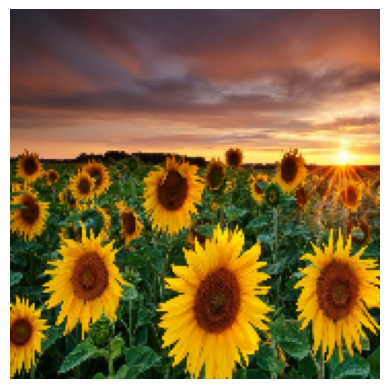

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
Loại hoa dự đoán: sunflowers
Độ chính xác: 100.00%


In [59]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

# Load the class labels that were saved with the model
with open('/content/flower_class_labels.pkl', 'rb') as f:
    class_indices_loaded = pickle.load(f)
# Reconstruct class_labels list from the loaded dictionary, ensuring correct order
class_labels = [name for name, idx in sorted(class_indices_loaded.items(), key=lambda item: item[1])]

# NOTE: Ensure this path points to an existing image file.
path = "/content/Hướng dương.png"

# Load the model
model = load_model('/content/my_flower_model.h5')

# Load image with target size matching the model's input size (img_width, img_height are 200, 200)
img = load_img(path, target_size=(img_width, img_height))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

predicted_class_idx = np.argmax(score)
flower_name = class_labels[predicted_class_idx]
confidence = 100 * score[predicted_class_idx].numpy()

print(f"Loại hoa dự đoán: {flower_name}")
print(f"Độ chính xác: {confidence:.2f}%")